In [ ]:
from torchvision import transforms
import get_data
import coatnet
from torch import nn
from torch import optim
from torch.optim import lr_scheduler
import train


# Define image augmentation for training data
train_transforms = transforms.Compose([
    transforms.Resize(224), 
    transforms.RandAugment(2, 20),
    transforms.ToTensor()
])
image_transforms = {
    "train": train_transforms,
    "val": None,
    "test": None
}

# Load the data
splits = get_data.generate_train_val_test_splits(debug=False)
data_loaders = get_data.load_data(splits, image_transforms=image_transforms)

# Define model
args = {
    "image_size": (224, 224),
    "in_channels": 3,
    "num_blocks": [2, 2, 3, 5, 2],
    "channels": [64, 96, 192, 384, 768],
    "num_classes": 10,
    "block_types": ["C", "C", "C", "T"]
}
model = coatnet.CoAtNet(
    image_size=args["image_size"],
    in_channels=args["in_channels"],
    num_blocks=args["num_blocks"],
    channels=args["channels"],
    num_classes=args["num_classes"],
    block_types=args["block_types"]
)

# Define optimizer and loss
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Define sequential scheduler for linear warmup over 10 epochs 
# and cosine decay over 90 epochs
lr_lambda = lambda epoch: (epoch + 1) / 10
warmup_scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
decay_scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=90, eta_min=1e-5)
scheduler = lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, decay_scheduler], milestones=[10])

# Train model
n_epochs = 100
history = train.train(
    model=model, 
    data_loaders=data_loaders, 
    n_epochs=n_epochs,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler
)

C:\Users\nikhi\.astroNN\datasets\Galaxy10_DECals.h5 was found!


c:\Users\nikhi\anaconda3\envs\galaxy10-cli\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)


Epoch [1/100]: Train Loss = 2.9820; Train Acc. = 0.0312
Epoch [1/100]: Val Loss = 2.3194; Val Acc. = 0.2188

Epoch [2/100]: Train Loss = 2.7050; Train Acc. = 0.1562
Epoch [2/100]: Val Loss = 2.3681; Val Acc. = 0.2188

Epoch [3/100]: Train Loss = 3.1473; Train Acc. = 0.1875
Epoch [3/100]: Val Loss = 2.4390; Val Acc. = 0.1875

Epoch [4/100]: Train Loss = 2.8588; Train Acc. = 0.1250
Epoch [4/100]: Val Loss = 2.5318; Val Acc. = 0.1875

Epoch [5/100]: Train Loss = 3.8971; Train Acc. = 0.0938
Epoch [5/100]: Val Loss = 2.7760; Val Acc. = 0.1875

Epoch [6/100]: Train Loss = 3.3972; Train Acc. = 0.1250
Epoch [6/100]: Val Loss = 3.0513; Val Acc. = 0.1875

Epoch [7/100]: Train Loss = 3.1005; Train Acc. = 0.1875
Epoch [7/100]: Val Loss = 2.7509; Val Acc. = 0.1875

Epoch [8/100]: Train Loss = 2.7068; Train Acc. = 0.2188
Epoch [8/100]: Val Loss = 2.3994; Val Acc. = 0.1875

Epoch [9/100]: Train Loss = 3.1610; Train Acc. = 0.2812
Epoch [9/100]: Val Loss = 2.4965; Val Acc. = 0.2188



c:\Users\nikhi\anaconda3\envs\galaxy10-cli\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.


Epoch [10/100]: Train Loss = 2.6808; Train Acc. = 0.1250
Epoch [10/100]: Val Loss = 2.8506; Val Acc. = 0.0000

Epoch [11/100]: Train Loss = 2.5894; Train Acc. = 0.1875
Epoch [11/100]: Val Loss = 5.0688; Val Acc. = 0.0000

Epoch [12/100]: Train Loss = 2.9491; Train Acc. = 0.1875
Epoch [12/100]: Val Loss = 2.7504; Val Acc. = 0.2188

Epoch [13/100]: Train Loss = 3.0717; Train Acc. = 0.2812
Epoch [13/100]: Val Loss = 2.9725; Val Acc. = 0.2188

Epoch [14/100]: Train Loss = 3.0794; Train Acc. = 0.2500
Epoch [14/100]: Val Loss = 2.8013; Val Acc. = 0.1250

Epoch [15/100]: Train Loss = 2.6811; Train Acc. = 0.0938
Epoch [15/100]: Val Loss = 3.2849; Val Acc. = 0.1250

Epoch [16/100]: Train Loss = 2.6545; Train Acc. = 0.2188
Epoch [16/100]: Val Loss = 2.4139; Val Acc. = 0.1250

Epoch [17/100]: Train Loss = 2.3374; Train Acc. = 0.1562
Epoch [17/100]: Val Loss = 2.3562; Val Acc. = 0.2188

Epoch [18/100]: Train Loss = 2.4694; Train Acc. = 0.2188
Epoch [18/100]: Val Loss = 2.1878; Val Acc. = 0.1562

E

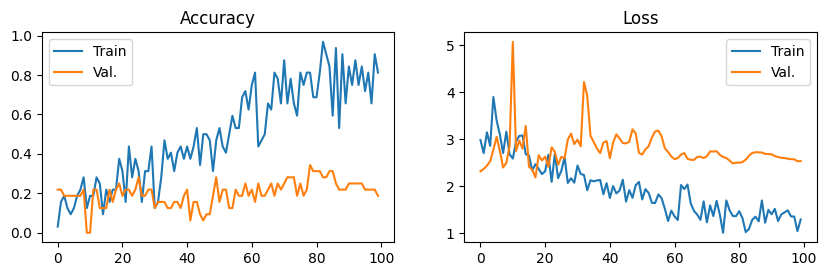

In [2]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(history["train_accuracy"], label="Train")
plt.plot(history["val_accuracy"], label="Val.")
plt.legend()
plt.title("Accuracy")
plt.subplot(2, 2, 2)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val.")
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
import torch


# Save model state dict
PATH = "saved_models/coatnet.new.2.pt"
torch.save(
    {
        "model_state": model.state_dict(),
        "model_args": args,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "epoch": n_epochs
    }, 
    PATH
)

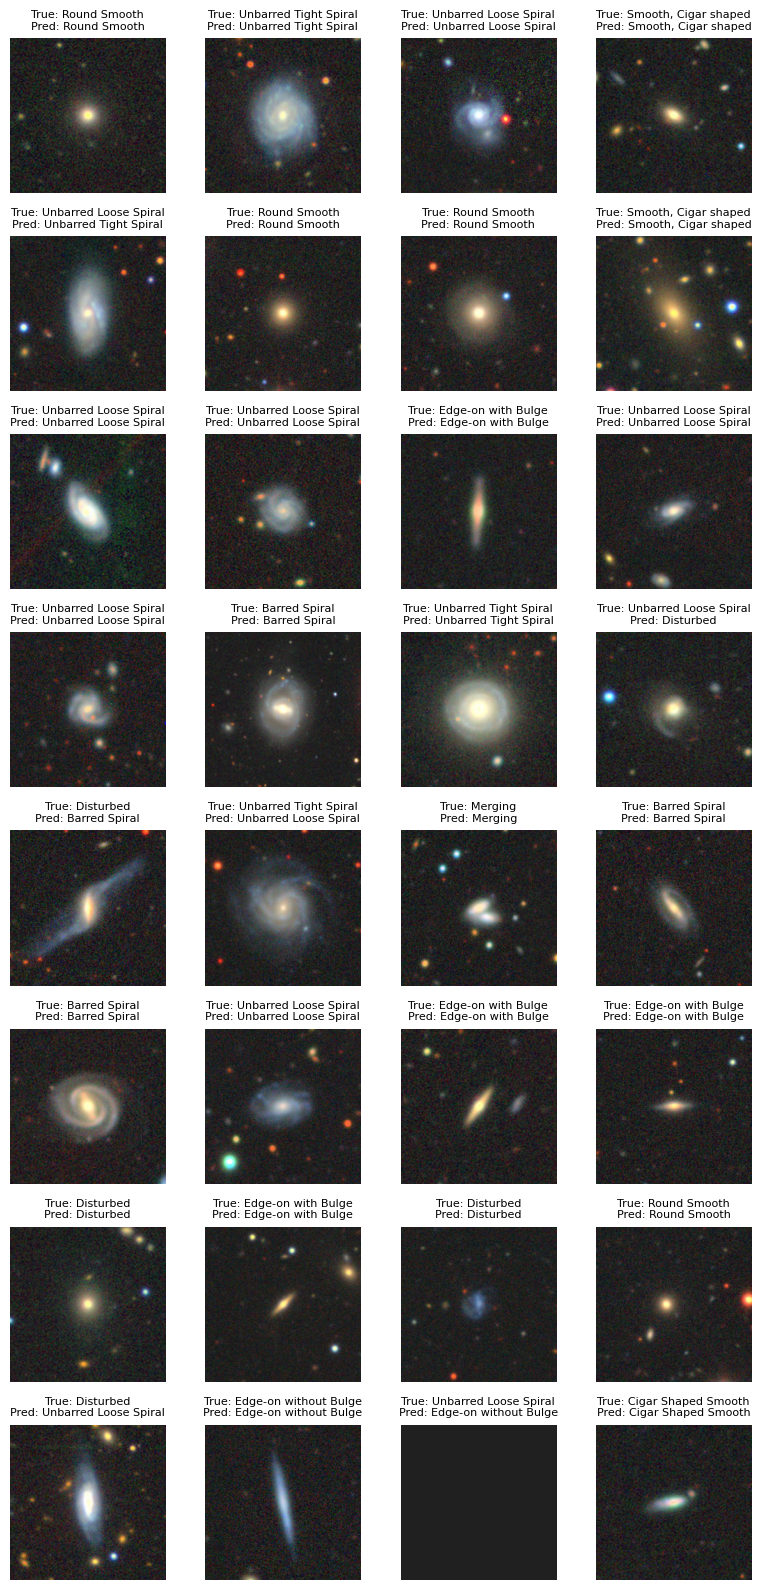

In [16]:
import understand


understand.inspect_predictions(model=model, data_loader=data_loaders["val"], batches=2)

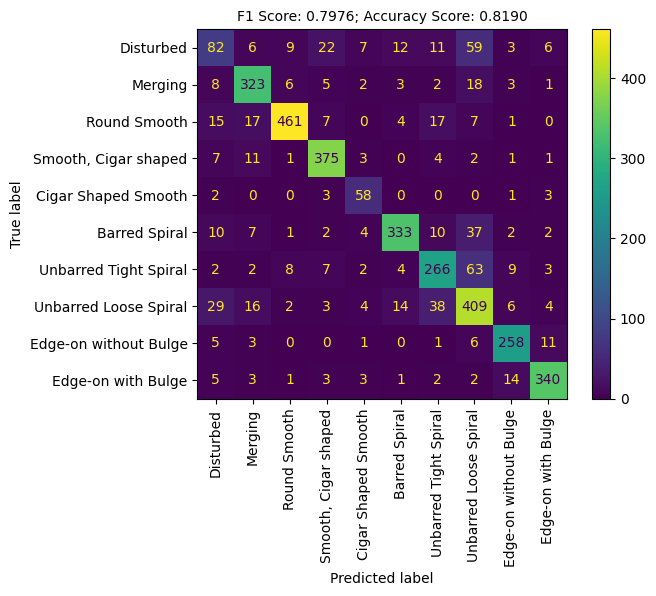

In [17]:
import train
from sklearn import metrics
import matplotlib.pyplot as plt
from astroNN.datasets import galaxy10


y_hat, y = train.predict(model, data_loaders["val"])
f1_score = metrics.f1_score(y, y_hat, average="macro")
accuracy_score = metrics.accuracy_score(y, y_hat)

# Display confusion matrix
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=y_hat,
    display_labels=[galaxy10.galaxy10cls_lookup(i) for i in range(10)],
    xticks_rotation="vertical"
)
plt.title(f"F1 Score: {f1_score:.04f}; Accuracy Score: {accuracy_score:.04f}", fontsize=10)
plt.show()